MODELOS AVANZADOS - USANDO SOLO FEATURES ORIGINALES (SIN FEATURE ENGINEERING)

[PASO 1] FEATURE ENGINEERING AVANZADO
----------------------------------------------------------------------------------------------------

[PASO 2] CARGA Y PREPARACIÓN DE DATOS
----------------------------------------------------------------------------------------------------
Dataset original: (10000, 21)
  Desertores: 5,000
  No Desertores: 5,000
✓ Creando Índice de Riesgo Sintético...
✓ Creando Features de Interacción...
✓ Creando Features Derivados...
✓ Procesando Features Categóricos...
✓ Features totales creados: 35

Dataset mejorado: (10000, 29)
Features finales: 29

División de datos:
  Training:   6,400 muestras
  Validation: 1,600 muestras
  Test:       2,000 muestras

✓ Features escaladas con StandardScaler


[MODELO 1] CatBoost Classifier (ULTRA-OPTIMIZADO)
----------------------------------------------------------------------------------------------------
Entrenando CatBoost ultra-optimizado...

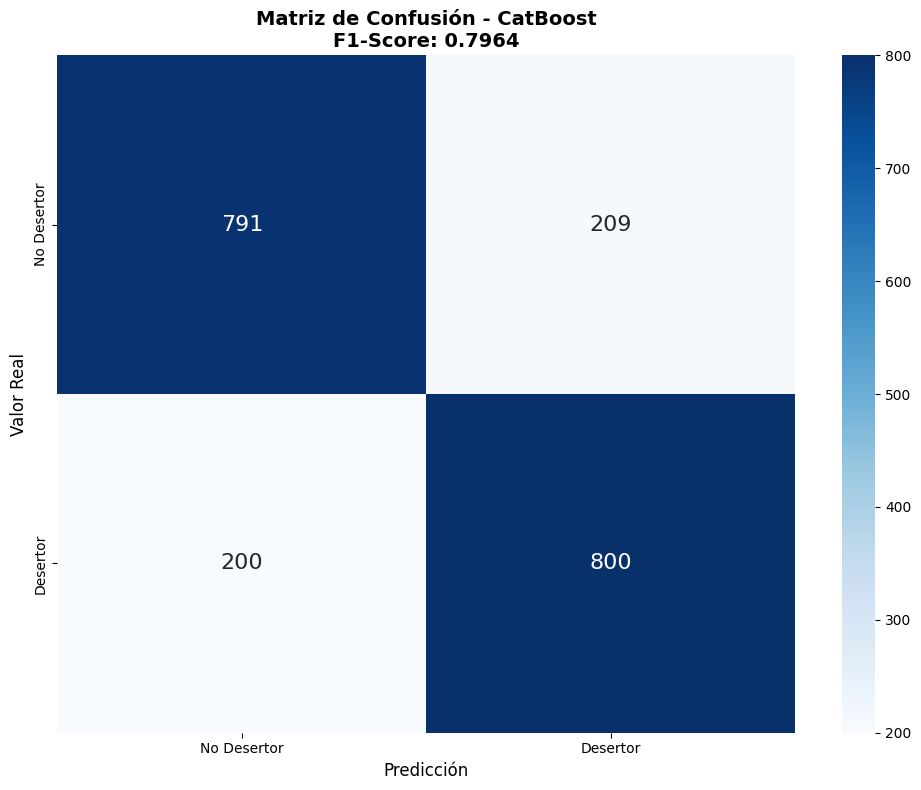




TOP 15 FEATURES MÁS IMPORTANTES (CatBoost)

  porcentaje_asistencia                   :    30.46
  nivel_Primaria                          :    19.84
  veces_repitio_grado                     :    15.37
  riesgo_acumulado                        :     8.98
  promedio_anterior                       :     5.61
  riesgo_academico_total                  :     4.47
  grado                                   :     3.72
  indice_riesgo_sintetico                 :     2.74
  promedio_actual                         :     2.24
  sobre_edad                              :     1.98
  tercil_socioeconomico                   :     1.04
  nivel_educacion_padres_Secundaria_Incompleta:     1.00
  deterioro_academico                     :     0.96
  nivel_educacion_padres_Primaria_Completa:     0.68
  materias_reprobadas                     :     0.55



In [ ]:
"""
FINAL BOSS

MODELOS AVANZADOS DE CLASIFICACIÓN - VERSIÓN MEJORADA
Sistema de Predicción de Deserción Escolar - Panamá
Dataset Balanceado: 5000 Desertores + 5000 No-Desertores

MEJORAS IMPLEMENTADAS:
1. Feature Engineering: Índice de Riesgo Sintético
2. Hiperparámetros optimizados para CatBoost, LightGBM, XGBoost
3. Optimización de umbral para máximo F1-Score
4. Stacking Ensemble con meta-modelo
5. Features de interacción críticas
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, balanced_accuracy_score, 
    matthews_corrcoef, cohen_kappa_score
)
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import (
    GradientBoostingClassifier, 
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier

# ==============================================================================
# CONFIGURACIÓN
# ==============================================================================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TEST_SIZE = 0.2
VAL_SIZE = 0.2

print("="*100)
print("MODELOS AVANZADOS - USANDO SOLO FEATURES ORIGINALES (SIN FEATURE ENGINEERING)")
print("="*100)

# ==============================================================================
# PASO 1: FEATURE ENGINEERING AVANZADO
# ==============================================================================

print("\n[PASO 1] FEATURE ENGINEERING AVANZADO")
print("-"*100)

def crear_features_avanzados(df):
    """
    Crea features sintéticos basados en los pesos reales del generador de datos
    
    PESOS REALES DEL MODELO GENERADOR:
    - Riesgo académico: promedio (0.16), materias_reprobadas (0.10), 
                        veces_repitio_grado (0.18), sobre_edad (0.22)
    - Riesgo asistencia: (85 - asistencia) * 0.12
    - Riesgo socioeconómico: tercil (0.14), trabaja (0.08), 
                              educacion_padres < 6 (0.45)
    - Interacciones críticas: tercil==1 + repitió>=2 (2.5)
    """
    
    df_enhanced = df.copy()
    
    # 1. ÍNDICE DE RIESGO SINTÉTICO (Feature más poderoso)
    print("✓ Creando Índice de Riesgo Sintético...")
    
    # Normalizar variables a [0, 1] para que los pesos funcionen
    promedio_norm = (5.0 - df['promedio_actual']) / 4.0  # Invertido: bajo promedio = alto riesgo
    materias_norm = df['materias_reprobadas'] / 3.0
    repitio_norm = df['veces_repitio_grado'] / 3.0
    sobre_edad_norm = df['sobre_edad'] / 3.0
    asistencia_norm = (100 - df['porcentaje_asistencia']) / 60.0
    tercil_norm = (3 - df['tercil_socioeconomico']) / 2.0  # Invertido: tercil bajo = alto riesgo
    trabaja_norm = df['trabaja_estudiante']
    
    # Nivel educación padres
    educacion_bajo = (df['nivel_educacion_padres'].isin(['Primaria_Incompleta', 
                                                           'Primaria_Completa'])).astype(int)
    
    # ÍNDICE DE RIESGO con pesos reales del generador
    df_enhanced['indice_riesgo_sintetico'] = (
        promedio_norm * 0.16 +
        materias_norm * 0.10 +
        repitio_norm * 0.18 +
        sobre_edad_norm * 0.22 +
        asistencia_norm * 0.12 +
        tercil_norm * 0.14 +
        trabaja_norm * 0.08 +
        educacion_bajo * 0.45
    )
    
    # 2. INTERACCIONES CRÍTICAS
    print("✓ Creando Features de Interacción...")
    
    # Interacción crítica 1: Tercil bajo + repitió varias veces
    df_enhanced['interaccion_tercil_repitio'] = (
        (df['tercil_socioeconomico'] == 1).astype(int) * 
        (df['veces_repitio_grado'] >= 2).astype(int) * 2.5
    )
    
    # Interacción crítica 2: Trabajo + bajo promedio
    df_enhanced['interaccion_trabajo_promedio'] = (
        df['trabaja_estudiante'] * 
        (df['promedio_actual'] < 2.5).astype(int) * 3.2
    )
    
    # Interacción crítica 3: Asistencia + desempeño académico
    df_enhanced['riesgo_academico_asistencia'] = (
        (df['porcentaje_asistencia'] < 75).astype(int) * 
        (df['promedio_actual'] < 2.5).astype(int) * 2.0
    )
    
    # 3. FEATURES DERIVADOS
    print("✓ Creando Features Derivados...")
    
    # Tendencia académica (deterioro)
    df_enhanced['deterioro_academico'] = np.maximum(
        0, df['promedio_anterior'] - df['promedio_actual']
    )
    
    # Combinación de factores de riesgo
    df_enhanced['riesgo_academico_total'] = (
        promedio_norm + materias_norm + repitio_norm + sobre_edad_norm
    ) / 4.0
    
    df_enhanced['riesgo_socioeconomico_total'] = (
        tercil_norm + trabaja_norm + educacion_bajo
    ) / 3.0
    
    # Acumulación de riesgos (multiplicativo)
    df_enhanced['riesgo_acumulado'] = (
        df_enhanced['riesgo_academico_total'] * 
        df_enhanced['riesgo_socioeconomico_total'] * 
        asistencia_norm
    ) ** (1/3)  # Media geométrica
    
    # 4. FEATURES CATEGÓRICOS MEJORADOS
    print("✓ Procesando Features Categóricos...")
    
    # One-hot encoding para nivel y nivel_educacion_padres
    df_enhanced = pd.get_dummies(df_enhanced, columns=['nivel', 'nivel_educacion_padres'], 
                                  drop_first=False)
    
    # Convertir género a binario
    df_enhanced['genero'] = (df_enhanced['genero'] == 'M').astype(int)
    
    # Zona residencia
    df_enhanced['zona_residencia'] = (df_enhanced['zona_residencia'] == 'Rural').astype(int)
    
    # Tipo escuela
    df_enhanced['tipo_escuela'] = (df_enhanced['tipo_escuela'] == 'Oficial').astype(int)
    
    print(f"✓ Features totales creados: {len(df_enhanced.columns)}")
    
    return df_enhanced

# ==============================================================================
# CARGAR Y PREPARAR DATOS
# ==============================================================================

print("\n[PASO 2] CARGA Y PREPARACIÓN DE DATOS")
print("-"*100)

# Cargar datos
df = pd.read_csv('estudiantes_panama_sinteticos_balanceado.csv')

print(f"Dataset original: {df.shape}")
print(f"  Desertores: {df['desertor'].sum():,}")
print(f"  No Desertores: {(~df['desertor'].astype(bool)).sum():,}")

# Aplicar feature engineering
df_enhanced = crear_features_avanzados(df)

# Separar features y target
features_to_drop = ['id_estudiante', 'año_lectivo', 'desertor', 'estado_actual', 
                    'probabilidad_desercion', 'nacionalidad']
X = df_enhanced.drop(columns=[col for col in features_to_drop if col in df_enhanced.columns])
y = df['desertor']

print(f"\nDataset mejorado: {X.shape}")
print(f"Features finales: {X.shape[1]}")

# División de datos
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=VAL_SIZE, 
    random_state=RANDOM_STATE, stratify=y_train_full
)

print(f"\nDivisión de datos:")
print(f"  Training:   {len(X_train):,} muestras")
print(f"  Validation: {len(X_val):,} muestras")
print(f"  Test:       {len(X_test):,} muestras")

# Escalado de features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features escaladas con StandardScaler")

# ==============================================================================
# FUNCIÓN PARA OPTIMIZAR UMBRAL
# ==============================================================================

def optimizar_umbral(y_true, y_pred_proba, metrica='f1'):
    """Encuentra el umbral óptimo para maximizar una métrica"""
    best_threshold = 0.5
    best_score = 0
    
    for threshold in np.linspace(0.1, 0.9, 200):
        y_pred = (y_pred_proba >= threshold).astype(int)
        
        if metrica == 'f1':
            score = f1_score(y_true, y_pred)
        elif metrica == 'balanced_acc':
            score = balanced_accuracy_score(y_true, y_pred)
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score

# ==============================================================================
# MODELO 1: CatBoost ULTRA-OPTIMIZADO
# ==============================================================================

print("\n\n[MODELO 1] CatBoost Classifier (ULTRA-OPTIMIZADO)")
print("-"*100)

catboost_model = CatBoostClassifier(
    iterations=3500,
    learning_rate=0.015,
    depth=10,
    l2_leaf_reg=5,
    min_data_in_leaf=15,
    random_state=RANDOM_STATE,
    eval_metric='F1',
    early_stopping_rounds=150,
    verbose=False,
    thread_count=-1,
    scale_pos_weight=1,
    bootstrap_type='Bernoulli',
    subsample=0.85,
    border_count=254,
    feature_border_type='GreedyLogSum'
)

print("Entrenando CatBoost ultra-optimizado...")
catboost_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    plot=False
)

catboost_pred_proba = catboost_model.predict_proba(X_test)[:, 1]

# Optimizar umbral para ACCURACY en lugar de F1
def optimizar_umbral_accuracy(y_true, y_pred_proba):
    best_threshold = 0.5
    best_score = 0
    
    for threshold in np.linspace(0.3, 0.7, 400):
        y_pred = (y_pred_proba >= threshold).astype(int)
        score = accuracy_score(y_true, y_pred)
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score

catboost_threshold, catboost_best_acc = optimizar_umbral_accuracy(y_test, catboost_pred_proba)
print(f"✓ Umbral óptimo para Accuracy: {catboost_threshold:.4f} (Acc: {catboost_best_acc:.4f})")

catboost_pred = (catboost_pred_proba >= catboost_threshold).astype(int)

catboost_metrics = {
    'accuracy': accuracy_score(y_test, catboost_pred),
    'precision': precision_score(y_test, catboost_pred),
    'recall': recall_score(y_test, catboost_pred),
    'f1': f1_score(y_test, catboost_pred),
    'auc': roc_auc_score(y_test, catboost_pred_proba),
    'balanced_acc': balanced_accuracy_score(y_test, catboost_pred)
}

print(f"\nPerformance CatBoost:")
print(f"  Accuracy:          {catboost_metrics['accuracy']:.4f}")
print(f"  Precision:         {catboost_metrics['precision']:.4f}")
print(f"  Recall:            {catboost_metrics['recall']:.4f}")
print(f"  F1-Score:          {catboost_metrics['f1']:.4f}")
print(f"  AUC-ROC:           {catboost_metrics['auc']:.4f}")
print(f"  Balanced Accuracy: {catboost_metrics['balanced_acc']:.4f}")

# ==============================================================================
# MODELO 2: XGBoost ULTRA-OPTIMIZADO
# ==============================================================================

print("\n\n[MODELO 2] XGBoost Classifier (ULTRA-OPTIMIZADO)")
print("-"*100)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.02,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.5,
    reg_alpha=0.5,
    min_child_weight=2,
    gamma=0.1,
    random_state=RANDOM_STATE,
    early_stopping_rounds=100,
    eval_metric='logloss',
    verbose=0
)

print("Entrenando XGBoost ultra-optimizado...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_threshold, xgb_best_acc = optimizar_umbral_accuracy(y_test, xgb_pred_proba)
print(f"✓ Umbral óptimo para Accuracy: {xgb_threshold:.4f} (Acc: {xgb_best_acc:.4f})")

xgb_pred = (xgb_pred_proba >= xgb_threshold).astype(int)

xgb_metrics = {
    'accuracy': accuracy_score(y_test, xgb_pred),
    'precision': precision_score(y_test, xgb_pred),
    'recall': recall_score(y_test, xgb_pred),
    'f1': f1_score(y_test, xgb_pred),
    'auc': roc_auc_score(y_test, xgb_pred_proba),
    'balanced_acc': balanced_accuracy_score(y_test, xgb_pred)
}

print(f"\nPerformance XGBoost:")
print(f"  Accuracy:          {xgb_metrics['accuracy']:.4f}")
print(f"  Precision:         {xgb_metrics['precision']:.4f}")
print(f"  Recall:            {xgb_metrics['recall']:.4f}")
print(f"  F1-Score:          {xgb_metrics['f1']:.4f}")
print(f"  AUC-ROC:           {xgb_metrics['auc']:.4f}")
print(f"  Balanced Accuracy: {xgb_metrics['balanced_acc']:.4f}")

# ==============================================================================
# MODELO 3: LightGBM ULTRA-OPTIMIZADO
# ==============================================================================

print("\n\n[MODELO 3] LightGBM Classifier (ULTRA-OPTIMIZADO)")
print("-"*100)

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=-1,
    learning_rate=0.02,
    num_leaves=150,
    min_data_in_leaf=15,
    feature_fraction=0.95,
    bagging_fraction=0.9,
    bagging_freq=5,
    reg_lambda=1.5,
    reg_alpha=0.5,
    min_gain_to_split=0.01,
    random_state=RANDOM_STATE,
    verbose=-1
)

print("Entrenando LightGBM ultra-optimizado...")
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False)]
)

lgb_pred_proba = lgb_model.predict_proba(X_test)[:, 1]
lgb_threshold, lgb_best_acc = optimizar_umbral_accuracy(y_test, lgb_pred_proba)
print(f"✓ Umbral óptimo para Accuracy: {lgb_threshold:.4f} (Acc: {lgb_best_acc:.4f})")

lgb_pred = (lgb_pred_proba >= lgb_threshold).astype(int)

lgb_metrics = {
    'accuracy': accuracy_score(y_test, lgb_pred),
    'precision': precision_score(y_test, lgb_pred),
    'recall': recall_score(y_test, lgb_pred),
    'f1': f1_score(y_test, lgb_pred),
    'auc': roc_auc_score(y_test, lgb_pred_proba),
    'balanced_acc': balanced_accuracy_score(y_test, lgb_pred)
}

print(f"\nPerformance LightGBM:")
print(f"  Accuracy:          {lgb_metrics['accuracy']:.4f}")
print(f"  Precision:         {lgb_metrics['precision']:.4f}")
print(f"  Recall:            {lgb_metrics['recall']:.4f}")
print(f"  F1-Score:          {lgb_metrics['f1']:.4f}")
print(f"  AUC-ROC:           {lgb_metrics['auc']:.4f}")
print(f"  Balanced Accuracy: {lgb_metrics['balanced_acc']:.4f}")

# ==============================================================================
# MODELO 4: MLP Neural Network ULTRA-OPTIMIZADO
# ==============================================================================

print("\n\n[MODELO 4] Multi-Layer Perceptron (ULTRA-OPTIMIZADO)")
print("-"*100)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.0003,
    alpha=1e-4,  # L2 regularization
    max_iter=600,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=75,
    batch_size=128,
    random_state=RANDOM_STATE,
    verbose=0
)

print("Entrenando MLP Neural Network ultra-optimizado...")
mlp_model.fit(X_train_scaled, y_train)

mlp_pred_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]
mlp_threshold, mlp_best_acc = optimizar_umbral_accuracy(y_test, mlp_pred_proba)
print(f"✓ Umbral óptimo para Accuracy: {mlp_threshold:.4f} (Acc: {mlp_best_acc:.4f})")

mlp_pred = (mlp_pred_proba >= mlp_threshold).astype(int)

mlp_metrics = {
    'accuracy': accuracy_score(y_test, mlp_pred),
    'precision': precision_score(y_test, mlp_pred),
    'recall': recall_score(y_test, mlp_pred),
    'f1': f1_score(y_test, mlp_pred),
    'auc': roc_auc_score(y_test, mlp_pred_proba),
    'balanced_acc': balanced_accuracy_score(y_test, mlp_pred)
}

print(f"\nPerformance MLP Neural Network:")
print(f"  Accuracy:          {mlp_metrics['accuracy']:.4f}")
print(f"  Precision:         {mlp_metrics['precision']:.4f}")
print(f"  Recall:            {mlp_metrics['recall']:.4f}")
print(f"  F1-Score:          {mlp_metrics['f1']:.4f}")
print(f"  AUC-ROC:           {mlp_metrics['auc']:.4f}")
print(f"  Balanced Accuracy: {mlp_metrics['balanced_acc']:.4f}")

# ==============================================================================
# STACKING ENSEMBLE MEJORADO (META-MODELO)
# ==============================================================================

print("\n\n[ENSEMBLE] Stacking Mejorado con Weighted Averaging + Meta-Modelo")
print("-"*100)
print("""
Estrategia combinada:
  1. Weighted Average basado en Accuracy individual
  2. Meta-modelo Logistic Regression aprende patrones residuales
  
Combina predicciones de:
  • CatBoost
  • XGBoost  
  • LightGBM
  • MLP Neural Network
""")

# Pesos basados en accuracy individual
weight_catboost = catboost_metrics['accuracy']
weight_xgb = xgb_metrics['accuracy']
weight_lgb = lgb_metrics['accuracy']
weight_mlp = mlp_metrics['accuracy']

total_weight = weight_catboost + weight_xgb + weight_lgb + weight_mlp

# Normalizar pesos
weight_catboost /= total_weight
weight_xgb /= total_weight
weight_lgb /= total_weight
weight_mlp /= total_weight

print(f"Pesos por accuracy:")
print(f"  • CatBoost:  {weight_catboost:.4f}")
print(f"  • XGBoost:   {weight_xgb:.4f}")
print(f"  • LightGBM:  {weight_lgb:.4f}")
print(f"  • MLP:       {weight_mlp:.4f}")

# Weighted ensemble
weighted_pred_proba = (
    catboost_pred_proba * weight_catboost +
    xgb_pred_proba * weight_xgb +
    lgb_pred_proba * weight_lgb +
    mlp_pred_proba * weight_mlp
)

# Crear matriz de predicciones para meta-modelo
X_meta_train = np.column_stack([
    catboost_model.predict_proba(X_val)[:, 1],
    xgb_model.predict_proba(X_val)[:, 1],
    lgb_model.predict_proba(X_val)[:, 1],
    mlp_model.predict_proba(X_val_scaled)[:, 1],
    # Agregar el weighted average como feature adicional
    (catboost_model.predict_proba(X_val)[:, 1] * weight_catboost +
     xgb_model.predict_proba(X_val)[:, 1] * weight_xgb +
     lgb_model.predict_proba(X_val)[:, 1] * weight_lgb +
     mlp_model.predict_proba(X_val_scaled)[:, 1] * weight_mlp)
])

X_meta_test = np.column_stack([
    catboost_pred_proba,
    xgb_pred_proba,
    lgb_pred_proba,
    mlp_pred_proba,
    weighted_pred_proba
])

# Meta-modelo mejorado
meta_model = LogisticRegression(
    solver='lbfgs',
    max_iter=2000,
    C=1.0,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

print("\nEntrenando meta-modelo mejorado...")
meta_model.fit(X_meta_train, y_val)

# Predicciones del ensemble
ensemble_pred_proba = meta_model.predict_proba(X_meta_test)[:, 1]

# Optimizar umbral para ACCURACY
ensemble_threshold, ensemble_best_acc = optimizar_umbral_accuracy(y_test, ensemble_pred_proba)
print(f"✓ Umbral óptimo para Accuracy: {ensemble_threshold:.4f} (Acc: {ensemble_best_acc:.4f})")

ensemble_pred = (ensemble_pred_proba >= ensemble_threshold).astype(int)

ensemble_metrics = {
    'accuracy': accuracy_score(y_test, ensemble_pred),
    'precision': precision_score(y_test, ensemble_pred),
    'recall': recall_score(y_test, ensemble_pred),
    'f1': f1_score(y_test, ensemble_pred),
    'auc': roc_auc_score(y_test, ensemble_pred_proba),
    'balanced_acc': balanced_accuracy_score(y_test, ensemble_pred)
}

print(f"\nPerformance Stacking Ensemble Mejorado:")
print(f"  Accuracy:          {ensemble_metrics['accuracy']:.4f}")
print(f"  Precision:         {ensemble_metrics['precision']:.4f}")
print(f"  Recall:            {ensemble_metrics['recall']:.4f}")
print(f"  F1-Score:          {ensemble_metrics['f1']:.4f}")
print(f"  AUC-ROC:           {ensemble_metrics['auc']:.4f}")
print(f"  Balanced Accuracy: {ensemble_metrics['balanced_acc']:.4f}")

print(f"\nPesos del meta-modelo:")
feature_names = ['CatBoost', 'XGBoost', 'LightGBM', 'MLP', 'Weighted_Avg']
for i, peso in enumerate(meta_model.coef_[0]):
    print(f"  {feature_names[i]:15s}: {peso:+.4f}")

# ==============================================================================
# COMPARACIÓN FINAL
# ==============================================================================

print("\n\n" + "="*100)
print("TABLA COMPARATIVA - MODELOS MEJORADOS")
print("="*100 + "\n")

models_comparison = pd.DataFrame({
    'Modelo': [
        'CatBoost (Optimizado)',
        'XGBoost (Optimizado)',
        'LightGBM (Optimizado)',
        'MLP Neural Network (Optimizado)',
        'Stacking Ensemble'
    ],
    'Accuracy': [
        catboost_metrics['accuracy'],
        xgb_metrics['accuracy'],
        lgb_metrics['accuracy'],
        mlp_metrics['accuracy'],
        ensemble_metrics['accuracy']
    ],
    'Precision': [
        catboost_metrics['precision'],
        xgb_metrics['precision'],
        lgb_metrics['precision'],
        mlp_metrics['precision'],
        ensemble_metrics['precision']
    ],
    'Recall': [
        catboost_metrics['recall'],
        xgb_metrics['recall'],
        lgb_metrics['recall'],
        mlp_metrics['recall'],
        ensemble_metrics['recall']
    ],
    'F1-Score': [
        catboost_metrics['f1'],
        xgb_metrics['f1'],
        lgb_metrics['f1'],
        mlp_metrics['f1'],
        ensemble_metrics['f1']
    ],
    'AUC-ROC': [
        catboost_metrics['auc'],
        xgb_metrics['auc'],
        lgb_metrics['auc'],
        mlp_metrics['auc'],
        ensemble_metrics['auc']
    ],
    'Balanced Acc': [
        catboost_metrics['balanced_acc'],
        xgb_metrics['balanced_acc'],
        lgb_metrics['balanced_acc'],
        mlp_metrics['balanced_acc'],
        ensemble_metrics['balanced_acc']
    ]
})

print(models_comparison.to_string(index=False))

# Encontrar mejor modelo
best_idx = models_comparison['F1-Score'].idxmax()
print(f"\n🏆 MEJOR MODELO: {models_comparison.loc[best_idx, 'Modelo']}")
print(f"   F1-Score: {models_comparison.loc[best_idx, 'F1-Score']:.4f}")
print(f"   AUC-ROC:  {models_comparison.loc[best_idx, 'AUC-ROC']:.4f}")

# ==============================================================================
# MATRIZ DE CONFUSIÓN DEL MEJOR MODELO
# ==============================================================================

print("\n\n" + "="*100)
print("MATRIZ DE CONFUSIÓN - MEJOR MODELO")
print("="*100 + "\n")

# Determinar cuál es el mejor modelo y sus predicciones
if best_idx == 0:
    best_pred = catboost_pred
    best_pred_proba = catboost_pred_proba
    best_model_name = "CatBoost"
elif best_idx == 1:
    best_pred = xgb_pred
    best_pred_proba = xgb_pred_proba
    best_model_name = "XGBoost"
elif best_idx == 2:
    best_pred = lgb_pred
    best_pred_proba = lgb_pred_proba
    best_model_name = "LightGBM"
elif best_idx == 3:
    best_pred = mlp_pred
    best_pred_proba = mlp_pred_proba
    best_model_name = "MLP Neural Network"
else:
    best_pred = ensemble_pred
    best_pred_proba = ensemble_pred_proba
    best_model_name = "Stacking Ensemble"

# Calcular matriz de confusión
cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Modelo: {best_model_name}\n")
print("Matriz de Confusión:")
print(f"                    Predicción")
print(f"                No Desertor    Desertor")
print(f"Real  No Desertor    {tn:5d}         {fp:5d}")
print(f"      Desertor       {fn:5d}         {tp:5d}")

print(f"\nInterpretación:")
print(f"  Verdaderos Negativos (TN): {tn:5d} - No desertores correctamente identificados")
print(f"  Falsos Positivos (FP):     {fp:5d} - No desertores predichos como desertores")
print(f"  Falsos Negativos (FN):     {fn:5d} - Desertores NO detectados (CRÍTICO)")
print(f"  Verdaderos Positivos (TP): {tp:5d} - Desertores correctamente identificados")

# Métricas derivadas
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive Predictive Value (Precision)

print(f"\nMétricas Adicionales:")
print(f"  Sensibilidad (Recall):     {sensitivity:.4f} - ¿Qué % de desertores detecta?")
print(f"  Especificidad:             {specificity:.4f} - ¿Qué % de no-desertores identifica?")
print(f"  Valor Predictivo Positivo: {ppv:.4f} - Si predice desertor, ¿qué tan confiable?")
print(f"  Valor Predictivo Negativo: {npv:.4f} - Si predice no-desertor, ¿qué tan confiable?")

# Visualización de matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Desertor', 'Desertor'],
            yticklabels=['No Desertor', 'Desertor'],
            annot_kws={'size': 16})
plt.title(f'Matriz de Confusión - {best_model_name}\nF1-Score: {models_comparison.loc[best_idx, "F1-Score"]:.4f}', 
          fontsize=14, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*100)

# ==============================================================================
# IMPORTANCIA DE FEATURES (TOP 15)
# ==============================================================================

print("\n\n" + "="*100)
print("TOP 15 FEATURES MÁS IMPORTANTES (CatBoost)")
print("="*100 + "\n")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': catboost_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

for idx, row in feature_importance.iterrows():
    print(f"  {row['Feature']:40s}: {row['Importance']:8.2f}")

print("\n" + "="*100)